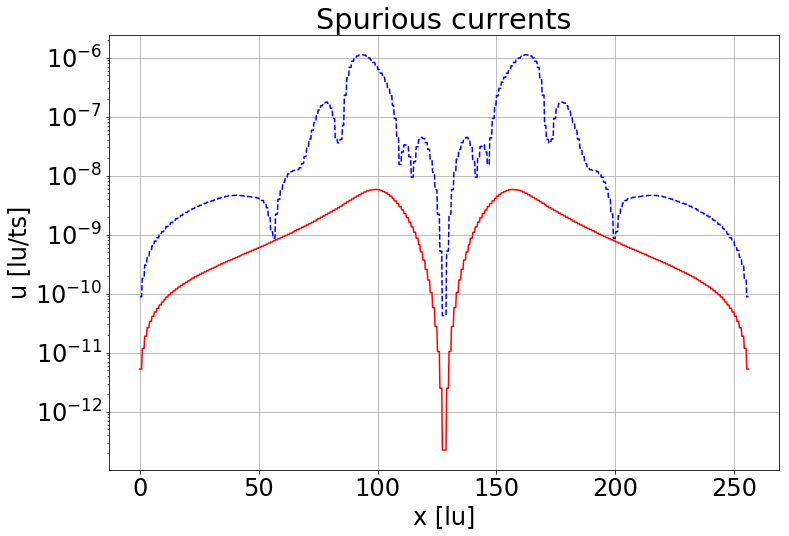

In [4]:

import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import csv

rho_ratio = '100'
v = '01666'

folder_path = os.path.join("../data_for_plots",
                           "moving_vs_resting_bubble",
                           "line_data_rho%s_v%s_circular_Ux001" % (rho_ratio, v))

frame_n = 999  # last time-frame


frame_cm = pd.read_csv(os.path.join(folder_path, "cm_resting.%d.csv" % frame_n), delimiter="\t")
frame_mrt = pd.read_csv(os.path.join(folder_path, "cm_resting_tau.%d.csv" % frame_n), delimiter="\t")
# frame_mrt = pd.read_csv(os.path.join(folder_path, "mrt_resting.%d.csv" % frame_n), delimiter="\t")

u_cm = np.sqrt(frame_cm['U:0']*frame_cm['U:0']+frame_cm['U:1']*frame_cm['U:1'])
u_mrt = np.sqrt(frame_mrt['U:0']*frame_mrt['U:0']+frame_mrt['U:1']*frame_mrt['U:1'])


# make plot
plt.rcParams.update({'font.size': 24})
plt.figure(figsize=(12, 8))

plt.semilogy(frame_cm['arc_length'], u_cm, color="red", marker="", linestyle="-")#, label='current model')
plt.semilogy(frame_mrt['arc_length'], u_mrt, color="blue", marker="", linestyle="--")#, label='MRT')
#
# plt.plot(frame_cm['arc_length'], u_cm, color="red", marker="", linestyle="-", label='current model')
# plt.plot(frame_mrt['arc_length'], u_mrt, color="blue", marker="o", linestyle='-',markevery=100, label='MRT')

plt.xlabel(r'x [lu]')
plt.ylabel(r'u [lu/ts]')

plt.title('Spurious currents')
plt.grid(True)
plt.legend()


# plt.text(0.0, 5E-6, r'$\rho^* = %s$' % rho_ratio)
fig = plt.gcf()  # get current figure
fig.savefig('spurious_currents_cm_vs_cm_tau_rho%s_v%s.png' % (rho_ratio, v))
plt.show()


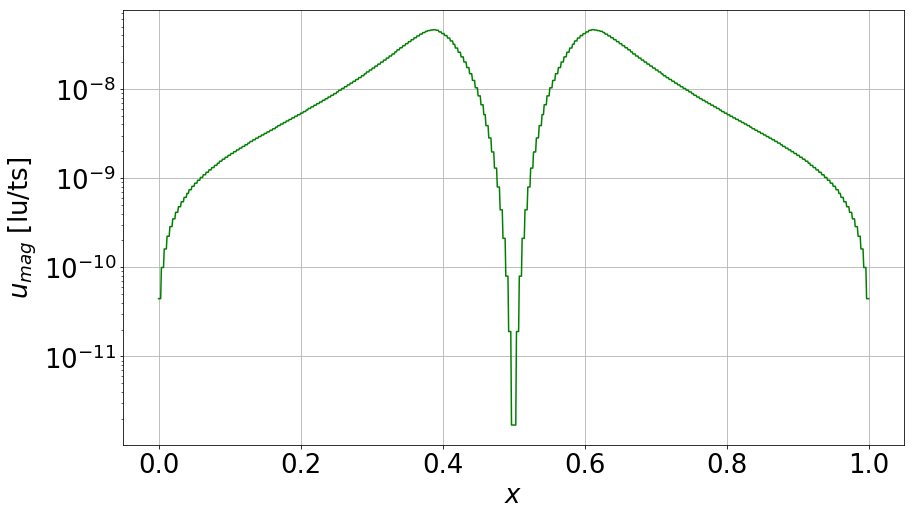

In [32]:
import matplotlib.pyplot as plt
import csv
import numpy as np
import os
import pandas as pd



folder = os.path.join("/home","ggruszczynski/","DATA_FOR_PLOTS", "relaxation_interpolation")
# x0, mrt_u_kinvisc = read_data(os.path.join(folder, "parasitic_mrt_kinvisc", "mrt_umag_spurious_kinvisc.csv"))
# x1, cm_u_kinvisc = read_data(os.path.join(folder, "parasitic_cm_kinvisc", "cm_umag_spurious_kinvisc.csv"))
# x2, cm_u_dynvisc = read_data(os.path.join(folder, "parasitic_cm_dynvisc", "cm_umag_spurious_dynvisc.csv"))

frame_mrt_u_kinvisc = pd.read_csv(os.path.join(folder, "parasitic_mrt_kinvisc", "mrt_umag_spurious_kinvisc.csv"), delimiter=",")
frame_cm_u_kinvisc = pd.read_csv(os.path.join(folder, "parasitic_cm_kinvisc", "cm_umag_spurious_kinvisc.csv"), delimiter=",")
frame_cm_u_dynvisc = pd.read_csv(os.path.join(folder, "parasitic_cm_kinvisc", "cm_umag_spurious_kinvisc.csv"), delimiter=",")

frame_mrt_u_kinvisc.drop_duplicates(subset=['arc_length', 'U_Magnitude'], keep=False)
# make plot
plt.rcParams.update({'font.size': 26})
plt.figure(figsize=(14, 8))
# plt.plot(rho_ratio, u_MRT_Guo, color="red", marker=".", linestyle="", label='u MRT linear relaxation')
# plt.semilogy(x0 / x0.max(), mrt_u_kinvisc.flatten(), marker="<", linestyle="-", color="red")#, label=r'$ eq23$')
plt.semilogy(frame_mrt_u_kinvisc['arc_length'] / frame_mrt_u_kinvisc['arc_length'].max(), frame_mrt_u_kinvisc['U_Magnitude'], color="green")#, label=r'$ eq25$')
# plt.semilogy(x2 / x2.max(), cm_u_dynvisc.flatten(), color="blue", linestyle=":")#, label=r'$ eq25$')

plt.xlabel(r'$x$')
plt.ylabel(r'$u_{mag}$ [lu/ts]')

# plt.title('Spurious Currents')
plt.grid(True)
#plt.legend()


# plt.text(0.0, 5E-6, r'$\rho^* = %s$' % rho_ratio)
fig = plt.gcf()  # get current figure
fig.savefig('spurious_currents.png')
plt.show()


In [53]:
import pandas as pd
folder = os.path.join("/home","ggruszczynski/","DATA_FOR_PLOTS", "relaxation_interpolation")
frame_cm_u_dynvisc = pd.read_csv(os.path.join(folder, "parasitic_cm_kinvisc", "cm_umag_spurious_kinvisc.csv"), delimiter=",")
frame_cm_u_dynvisc = frame_cm_u_dynvisc.round(10)
frame_cm_u_dynvisc.drop_duplicates(keep=False)
# frame_cm_u_dynvisc


,arc_length,U_Magnitude
0,0.000,0.000000e+00
1,0.256,0.000000e+00
2,0.512,0.000000e+00
3,0.768,0.000000e+00
4,1.024,1.000000e-10
5,1.280,1.000000e-10
6,1.536,1.000000e-10
7,1.792,1.000000e-10
8,2.048,2.000000e-10
9,2.304,2.000000e-10


In [10]:

frame_cm_u_dynvisc.max()

arc_length     2.560000e+02
U_Magnitude    4.608060e-08
dtype: float64

In [22]:
import pandas as pd
df = pd.DataFrame({"A":["foo", "foo", "foo", "bar"], "B":[0,1,1,1], "C":["A","A","B","A"]})
df


,A,B,C
0,foo,0,A
1,foo,1,A
2,foo,1,B
3,bar,1,A


In [29]:
df.drop_duplicates(subset=['B', 'C'], keep="first")


,A,B,C
0,foo,0,A
1,foo,1,A
2,foo,1,B
